In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
torch.manual_seed(0)

## 加载数据集

In [2]:
def load_data_fashion_mnist(batch_size, resize=None):
    trans = []
    if resize:
        trans.append(transforms.Resize(resize))
    trans.append(transforms.ToTensor())
    trans = transforms.Compose(trans)
    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=trans,
        download=True
    )
    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=trans,
        download=True
    )
    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    return train_iter, test_iter
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

## 初始化模型参数

In [3]:
num_inputs = 784      # 28 * 28
num_outputs = 10      # 10个类别
W = torch.normal(
    mean=0,
    std=0.01,
    size=(num_inputs, num_outputs),
    requires_grad=True
)
b = torch.zeros(
    num_outputs,
    requires_grad=True
)

## 手写softmax

In [4]:
def softmax(X):
    X = X - X.max(dim=1, keepdim=True).values#dim表示沿行取最大值，keepdim表示形状不变
    X_exp = torch.exp(X)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

## 定义模型

In [5]:
def net(X):
    X = X.reshape((-1, W.shape[0]))   # 拉平成 [batch_size, 784]
    logits = X @ W + b                # 线性部分
    return softmax(logits)            # 输出每个类别的概率

## 手写交叉熵损失

In [6]:
def cross_entropy(y_hat, y):
    idx = torch.arange(y_hat.shape[0])#就是为每行挂一个行索引
    return -torch.log(y_hat[idx, y] + 1e-9)

## 手写准确率

y_hat.type(y.dtype)：防错类型转换。在 PyTorch 中，如果两个张量的数据类型不严格一致（例如一个是 int32，一个是 int64），进行 == 比较时会直接引发系统报错（RuntimeError）。这一步强制将预测值的类型转换为与真实标签 y 完全一致。

== y：逐元素对比（Element-wise Comparison）。将预测出来的非线性向量与真实的标签向量进行比对。

cmp 的数据状态：生成一个形状为 [batch_size] 的布尔张量（Boolean Tensor）。预测正确的对应位置为 True，预测错误的对应位置为 False（例如：tensor([True, False, True])）。

In [7]:
def accuracy(y_hat, y):
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)#判断是否是二维矩阵且列数大于1，后返回每行最大值索引
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

## 累加器，用来统计 loss、正确数、样本数

*args（可变参数）：星号代表接收任意数量的入参，并将它们打包成一个元组（Tuple）。这使得你在调用时非常灵活，可以一次性传 2 个、3 个甚至更多变量。

zip(self.data, args)：将当前内存中的累加状态 self.data 和新传入的参数列表 args 按索引两两配对。

列表推导式内部逻辑：

遍历每一对配对好的老数据 a 和新数据 b。

float(b) 执行防御性类型转换，确保如果是从 PyTorch Tensor 传过来的标量也能安全转为标准 Python 浮 float 参与运算。

执行 a + float(b) 计算出新的累加值，并整体覆盖更新 self.data。

数据演进示例：
假设当前 self.data 为 [10.5, 80, 100]（总损失10.5，对了80个，共100样本）。
当前 Batch 跑完，新产生了三个指标：损失 2.1，对了 15 个，样本数 20。
调用 metric.add(2.1, 15, 20)：

zip 结果：[(10.5, 2.1), (80, 15), (100, 20)]

相加重组：[10.5+2.1, 80+15, 100+20]

更新后 self.data 变为：[12.6, 95.0, 120.0]

实现了 Python 的 __getitem__ 魔术方法。该方法直接将类对象重载为可支持方括号索引的对象。

物理行为：如果不写这个方法，你想看总损失必须写 metric.data[0]。而实现了这个方法后，你可以像操作普通原生列表一样，极其直接地写 metric[0]、metric[1] 来访问内部的值，语法上极大精简。

In [8]:
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [
            a + float(b)
            for a, b in zip(self.data, args)
        ]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

## 评估准确率

In [9]:
def evaluate_accuracy(net, data_iter):
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            metric.add(accuracy(y_hat, y), y.numel())#numel返回张量总个数
    return metric[0] / metric[1]

## SGD

In [11]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 训练一个epoch

In [12]:
def train_epoch_ch3(net, train_iter, loss, updater):
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        l.sum().backward()
        updater(X.shape[0])
        metric.add(
            l.sum(),
            accuracy(y_hat, y),
            y.numel()
        )
    train_loss = metric[0] / metric[2]
    train_acc = metric[1] / metric[2]
    return train_loss, train_acc

## 完整训练函数

In [13]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    history = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch_ch3(net,train_iter,loss,updater)
        test_acc = evaluate_accuracy(net, test_iter)
        history.append((train_loss, train_acc, test_acc))
        print(
            f"epoch {epoch + 1}, "
            f"loss {train_loss:.4f}, "
            f"train acc {train_acc:.4f}, "
            f"test acc {test_acc:.4f}"
        )
    return history

## 开始训练

In [14]:
lr = 0.1
def updater(batch_size):
    return sgd([W, b], lr, batch_size)
num_epochs = 10
history = train_ch3(
    net,
    train_iter,
    test_iter,
    cross_entropy,
    num_epochs,
    updater
)

C:\Users\hp\AppData\Local\Temp\ipykernel_20520\3961626867.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  a + float(b)


epoch 1, loss 0.7843, train acc 0.7490, test acc 0.7821
epoch 2, loss 0.5712, train acc 0.8124, test acc 0.8108
epoch 3, loss 0.5252, train acc 0.8255, test acc 0.8204
epoch 4, loss 0.5008, train acc 0.8316, test acc 0.8102
epoch 5, loss 0.4852, train acc 0.8369, test acc 0.8263
epoch 6, loss 0.4735, train acc 0.8404, test acc 0.8099
epoch 7, loss 0.4653, train acc 0.8431, test acc 0.8274
epoch 8, loss 0.4582, train acc 0.8457, test acc 0.8183
epoch 9, loss 0.4524, train acc 0.8461, test acc 0.8304
epoch 10, loss 0.4477, train acc 0.8482, test acc 0.8239


## 训练曲线

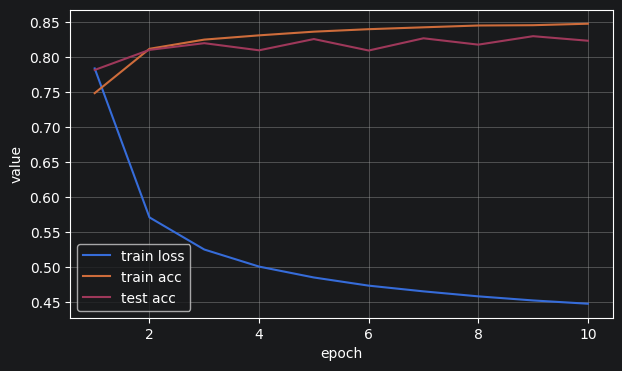

In [15]:
def plot_history(history):
    epochs = range(1, len(history) + 1)
    train_loss = [h[0] for h in history]
    train_acc = [h[1] for h in history]
    test_acc = [h[2] for h in history]
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_loss, label="train loss")
    plt.plot(epochs, train_acc, label="train acc")
    plt.plot(epochs, test_acc, label="test acc")
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.legend()
    plt.grid(True)
    plt.show()
plot_history(history)

## 标签映射

In [16]:
def get_fashion_mnist_labels(labels):
    text_labels = [
        "t-shirt",
        "trouser",
        "pullover",
        "dress",
        "coat",
        "sandal",
        "shirt",
        "sneaker",
        "bag",
        "ankle boot"
    ]
    return [text_labels[int(i)] for i in labels]

## 显示图片

In [17]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    if num_rows * num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, ax in enumerate(axes):
        img = imgs[i]
        if isinstance(img, torch.Tensor):
            img = img.squeeze().numpy()
        ax.imshow(img, cmap="gray")
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

## 预测展示

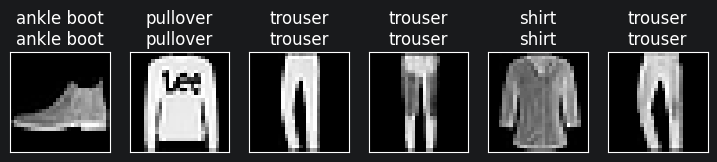

In [18]:
def predict_ch3(net, test_iter, n=6):
    for X, y in test_iter:
        break
    with torch.no_grad():
        pred = net(X).argmax(dim=1)
    true_labels = get_fashion_mnist_labels(y)
    pred_labels = get_fashion_mnist_labels(pred)
    titles = [
        true + "\n" + pred
        for true, pred in zip(true_labels, pred_labels)
    ]
    show_images(
        X[:n],
        1,
        n,
        titles=titles[:n]
    )
    plt.show()
predict_ch3(net, test_iter)